In [1]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

sys.path.insert(0, '/home/dominik/cc-workspace/coastal')
# cecelia IO helpers come from the installed `cecelia` package
# (pip install -e <cecelia-pineapple>/python) — no sys.path / CECELIA_APP needed.

%load_ext autoreload
%autoreload 2

from coastal import (
    # Data prep — single movie
    prepare_data_for_unet,
    normalize_and_project,
    VarianceMetricsConfig,
    compute_variance_metrics,
    # Data prep — multi-movie 4D
    prepare_data_for_unet_batch_4d,
    extract_sequences_from_volume,
    # Training
    train_test_split,
    train_test_split_per_movie,
    train_with_metrics,
    # Inference
    LearnedAffinityInference,
    TwoPassSegmentationInference,
    Inference3D,
    # Visualization & scoring
    visualize_frame_segmentation,
    plot_rgb_with_segmentation,
    score_segmentation,
    optimize_segmentation_cma,
)

print('✓ Imports successful')

✓ Imports successful


## Step 0: Load Image Data

Load from cecelia Zarr files. Update `base_dir` and `im_path` to match your dataset.

In [2]:
# config
# py.config_utils removed in new cecelia (was an unused import)

In [3]:
import cecelia.utils.zarr_utils as zarr_utils
import cecelia.utils.ome_xml_utils as ome_xml_utils
from cecelia.utils.dim_utils import DimUtils

# load volumes
uIDs = ['xh9GFi', 'N0VlpP', 'qcN9Br', 'ENH3fS', 'uNTqPu']

# T cells
base_dir = '/home/dominik/cecelia/projects/R0YiZv/ANALYSIS'
# B cells
# base_dir = '/home/dominik/cecelia/projects/ISTgZF/ANALYSIS'

version_num = 1

volumes = dict()
pix_res = dict()

for i in uIDs:
    im_path = os.path.join(base_dir, f'0/{i}/ccidCorrected.zarr')
    # task_dir = os.path.join(base_dir, str(version_num), f'{i}')
    
    # Get image data
    im, _ = zarr_utils.open_as_zarr(im_path, as_dask=True)

    # Get OME-XML and dimension info
    omexml = ome_xml_utils.parse_meta(im_path)
    dim_utils = DimUtils(omexml, use_channel_axis=True)
    dim_utils.calc_image_dimensions(im[0].shape)
    
    volumes[i] = im
    pix_res[i] = dim_utils.im_physical_sizes()

<zarr.hierarchy.Group '/' read-only>
[61, 4, 16, 628, 625]
[625, 628, 16, 4, 61]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[61, 4, 16, 671, 632]
[632, 671, 16, 4, 61]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[61, 4, 15, 623, 624]
[624, 623, 15, 4, 61]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[61, 4, 22, 778, 930]
[930, 778, 22, 4, 61]
['X', 'Y', 'Z', 'C', 'T']
<zarr.hierarchy.Group '/' read-only>
[61, 4, 16, 626, 627]
[627, 626, 16, 4, 61]
['X', 'Y', 'Z', 'C', 'T']


## Step 1 (Multi-Movie 4D): Extract Training Sequences

Extract 2D training sequences from a list of 4D volumes `[T, C, Z, Y, X]`.

- `n_sequences` z-slices are sampled **evenly across Z** per volume
- Each z-slice gets a **random start timepoint** → `seq_len` consecutive frames
- Optical flow is computed on the **mean-projected single channel**
- Variance metrics use the **full multi-channel** data
- Output format matches the existing `train_test_split_per_movie` + `train_with_metrics` pipeline

In [4]:
CH_INDICES = [0, 1, 2]  # first 3 channels; adjust if your 4th channel is DAPI / unwanted

# target_size=(H, W): resize all frames to a common spatial size.
# Required when volumes have different H×W and you want batch_size > 1.
# Set to None to keep original sizes — batch_size must then be 1 in training.
TARGET_SIZE = (384, 384)

In [ ]:
all_frames, all_temporal, all_variance, all_frames_multi = prepare_data_for_unet_batch_4d(
    volumes,                 # dict {uid: [full_res, half_res, ...]} or list — both accepted
    n_sequences=3,           # z-slices per volume (evenly spaced)
    seq_len=20,              # frames per sequence
    ch_indices=CH_INDICES,
    temporal_scales=[1, 2, 4],
    cumulative_window=2,
    random_seed=42,
    target_size=TARGET_SIZE,
)

print(f"Sequences: {len(all_frames)}  ({len(volumes)} volumes × 3 sequences)")
print(f"Frames per sequence: {all_frames[0].shape}")
print(f"Temporal metrics: {len(all_temporal[0][0])}")
print(f"Variance metrics: {len(all_variance[0][0])}")

In [ ]:
# No train/test split — use all 300 frames for training
train_frames  = np.concatenate(all_frames, axis=0)           # [N_total, H, W]
train_temporal = [m for seq in all_temporal for m in seq]    # flat list of dicts
train_variance = [m for seq in all_variance for m in seq]    # flat list of dicts

print(f"Training frames:  {train_frames.shape}")
print(f"Temporal metrics: {len(train_temporal)}")
print(f"Variance metrics: {len(train_variance)}")

# Pick one sequence for visual inspection / parameter tuning after training
EVAL_SEQ_IDX = 0
eval_frames_maxproj = all_frames[EVAL_SEQ_IDX]       # [20, H, W]
eval_temporal       = all_temporal[EVAL_SEQ_IDX]     # list of 20 dicts
eval_variance       = all_variance[EVAL_SEQ_IDX]     # list of 20 dicts
eval_frames_multi   = all_frames_multi[EVAL_SEQ_IDX] # [20, C, H, W]

In [ ]:
channel_names = ['CMAC', 'GFP', 'tdTomato']
n_t = 3  # timepoints to show

fig, axes = plt.subplots(n_t, 4, figsize=(16, 4 * n_t))
for t in range(n_t):
    for i, name in enumerate(channel_names):
        axes[t, i].imshow(eval_frames_multi[t, i], cmap='gray')
        axes[t, i].set_title(f't={t}  {name}' if t == 0 else '')
        axes[t, i].axis('off')
    axes[t, 3].imshow(eval_frames_maxproj[t], cmap='gray')
    axes[t, 3].set_title('Max projection' if t == 0 else '')
    axes[t, 3].axis('off')

plt.suptitle(f'Training sequence {EVAL_SEQ_IDX} — first {n_t} timepoints', fontsize=13)
plt.tight_layout()
plt.show()

## Step 2: Inspect Metrics

Sanity-check the computed metrics on the eval sequence before training.

- **Variance metrics**: per-channel softmax — encode color identity per pixel
- **Temporal metrics**: optical flow features — motion structure across frames

In [ ]:
# Variance metrics for one frame of the eval sequence
frame_idx = 0
var_dict = eval_variance[frame_idx]
var_keys = sorted(var_dict.keys())
channel_names = ['CMAC', 'GFP', 'tdTomato']

n_var = len(var_keys)
n_cols = 3
n_rows = 1 + (n_var + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for c in range(len(channel_names)):
    axes[c].imshow(eval_frames_multi[frame_idx, c], cmap='gray')
    axes[c].set_title(f'Raw: {channel_names[c]}')
    axes[c].axis('off')

for i, key in enumerate(var_keys):
    ax = axes[n_cols + i]
    arr = var_dict[key]
    im = ax.imshow(arr, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'{key}\n[{arr.min():.2f}, {arr.max():.2f}]  std={arr.std():.3f}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for j in range(n_cols + n_var, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Variance metrics — eval seq {EVAL_SEQ_IDX}, frame {frame_idx}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Temporal (optical flow) metrics for one frame of the eval sequence
frame_idx = 5
metrics_dict = eval_temporal[frame_idx]
metric_names = sorted(metrics_dict.keys())

valid_metrics = [
    (name, metrics_dict[name])
    for name in metric_names
    if isinstance(metrics_dict[name], np.ndarray) and metrics_dict[name].ndim == 2
]

n_metrics = len(valid_metrics)
cols = 3
rows = (n_metrics + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()

for idx, (name, arr) in enumerate(valid_metrics):
    im = axes[idx].imshow(arr, cmap='viridis')
    axes[idx].set_title(f'{name}\n(min={arr.min():.2f}, max={arr.max():.2f})')
    axes[idx].axis('off')
    plt.colorbar(im, ax=axes[idx])

for idx in range(n_metrics, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Temporal metrics — eval seq {EVAL_SEQ_IDX}, frame {frame_idx}', fontsize=13)
plt.tight_layout()
plt.show()

## Step 3: Train UNet with Learned Embeddings

3-loss design:
- **IntensityLoss**: brightness / contrast / edge guidance
- **TemporalMetricsLoss**: contrastive on optical flow metrics
- **VarianceMetricsLoss**: windowed contrastive on color metrics (ground truth cell identity)

In [ ]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

NUM_EPOCHS = 80

model, history = train_with_metrics(
    train_frames,
    train_temporal,
    variance_metrics_norm=train_variance,
    num_epochs=NUM_EPOCHS,
    batch_size=4,
    embedding_dim=64,
    intensity_weight=1.0,
    temporal_weight=1.0,
    variance_weight=1.0,
    variance_window_size=32,
    variance_dropout_p=0.5,
    device='cuda' if torch.cuda.is_available() else 'cpu',
)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(history['total'],     'k-',  label='Total',    linewidth=2)
ax.plot(history['intensity'], 'b-',  label='Intensity', alpha=0.8)
ax.plot(history['temporal'],  'r-',  label='Temporal',  alpha=0.8)
ax.plot(history['variance'],  'g-',  label='Variance',  alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training losses')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
from coastal import save_model, load_model

# save_model(
#     model,
#     path="/home/dominik/Downloads/TMP/coastal_model.pt",
#     metadata={"num_epochs": NUM_EPOCHS, "target_size": TARGET_SIZE},
# )

# To reload later:
model = load_model("/home/dominik/Downloads/TMP/coastal_model.pt", device="cuda")

Metadata: {'num_epochs': 80, 'target_size': (384, 384)}
Model loaded from /home/dominik/Downloads/TMP/coastal_model.pt


In [9]:
# Metric importance: ablation study on probability map
# Zero each metric channel one at a time, measure prob map change.
# Variance channels are zeroed at inference; only temporal channels are ablated.
frame_idx = 4
frame = train_frames[frame_idx] if train_frames.ndim == 3 else train_frames[frame_idx, 0]
t_metrics = train_temporal[frame_idx]
n_variance = len(train_variance[frame_idx]) if train_variance else 0

frame_norm = (frame - frame.mean()) / (frame.std() + 1e-5)
frame_tensor = torch.from_numpy(frame_norm).float().unsqueeze(0).unsqueeze(0)

metric_names = sorted(t_metrics.keys())
metric_tensors = [
    torch.from_numpy(t_metrics[k]).float() if isinstance(t_metrics[k], np.ndarray)
    else t_metrics[k].float()
    for k in metric_names
]
metrics_stacked = torch.stack(metric_tensors, dim=0).unsqueeze(0)

# Variance channels zeroed — this is the inference-time input distribution
H, W = frame_tensor.shape[-2:]
variance_zeros = torch.zeros(1, n_variance, H, W)
full_input = torch.cat([frame_tensor, metrics_stacked, variance_zeros], dim=1)

_device = next(model.parameters()).device
model.eval()

with torch.no_grad():
    prob_baseline = torch.sigmoid(model(full_input.to(_device))[0])[0, 0].cpu().numpy()

importances = []
prob_ablated_maps = []
for i, name in enumerate(metric_names):
    ablated = full_input.clone().to(_device)
    ablated[:, 1 + i, :, :] = 0.0
    with torch.no_grad():
        prob_abl = torch.sigmoid(model(ablated)[0])[0, 0].cpu().numpy()
    importances.append(np.abs(prob_baseline - prob_abl).mean())
    prob_ablated_maps.append(prob_abl)

# --- Bar chart ---
sorted_idx = np.argsort(importances)[::-1]
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(metric_names)), [importances[i] for i in sorted_idx])
ax.set_xticks(range(len(metric_names)))
ax.set_xticklabels([metric_names[i] for i in sorted_idx], rotation=45, ha='right')
ax.set_ylabel('Mean |prob_full − prob_ablated|')
ax.set_title('Metric importance for probability map (channel ablation)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# --- Grid: baseline | ablated | diff for each metric ---
n_metrics = len(metric_names)
fig, axes = plt.subplots(n_metrics, 3, figsize=(12, 3.5 * n_metrics))
if n_metrics == 1:
    axes = axes[np.newaxis, :]

vmax_diff = max(np.abs(prob_baseline - m).max() for m in prob_ablated_maps) + 1e-5

for i, name in enumerate(metric_names):
    diff_map = prob_baseline - prob_ablated_maps[i]
    axes[i, 0].imshow(prob_baseline, cmap='hot', vmin=0, vmax=1)
    axes[i, 0].set_ylabel(name, fontsize=9)
    axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])
    if i == 0:
        axes[i, 0].set_title('Baseline')

    axes[i, 1].imshow(prob_ablated_maps[i], cmap='hot', vmin=0, vmax=1)
    axes[i, 1].set_xticks([]); axes[i, 1].set_yticks([])
    if i == 0:
        axes[i, 1].set_title('Without metric')

    im = axes[i, 2].imshow(diff_map, cmap='RdBu_r', vmin=-vmax_diff, vmax=vmax_diff)
    axes[i, 2].set_title(f'mean|Δ|={importances[i]:.4f}' if i == 0 else f'{importances[i]:.4f}')
    axes[i, 2].set_xticks([]); axes[i, 2].set_yticks([])

plt.suptitle('Per-metric ablation (red = prob drops without metric, blue = prob rises)', fontsize=11)
plt.tight_layout()
plt.show()


NameError: name 'train_frames' is not defined

## Step 4: Run Instance Segmentation Inference

Use two-pass strategy:
- **Pass 1**: Large seeds (32px), low affinity threshold → Find large cells
- **Pass 2**: Small seeds (8px), high affinity threshold → Find small fragments

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import umap
import torch

# --- pick a frame from the eval sequence ---
FRAME_IDX = 0
frame_hw = eval_frames_maxproj[FRAME_IDX]
t_metrics = eval_temporal[FRAME_IDX]
v_metrics = eval_variance[FRAME_IDX]

# multi-channel frame for dominant-channel coloring
frame_mc = eval_frames_multi[FRAME_IDX]    # [C, H, W]
C, H, W = frame_mc.shape
dominant_channel = frame_mc.argmax(axis=0) # [H, W]

# ── 1. Variance metric maps ──────────────────────────────────────────────────
show_keys = sorted(v_metrics.keys())
if show_keys:
    fig, axes = plt.subplots(1, len(show_keys), figsize=(4 * len(show_keys), 4))
    if len(show_keys) == 1:
        axes = [axes]
    for ax, k in zip(axes, show_keys):
        ax.imshow(v_metrics[k], cmap='viridis', vmin=0, vmax=1)
        ax.set_title(k); ax.axis('off')
    plt.suptitle('Variance metrics'); plt.tight_layout(); plt.show()

# ── 2. UMAP of embeddings colored by dominant channel ───────────────────────
frame_norm = (frame_hw - frame_hw.min()) / (frame_hw.max() - frame_hw.min() + 1e-5)
if frame_norm.ndim == 2:
    frame_t = torch.from_numpy(frame_norm).float().unsqueeze(0).unsqueeze(0)
else:
    frame_t = torch.from_numpy(frame_norm).float().unsqueeze(0)

metric_list = [torch.from_numpy(np.array(v)).float()
               for k, v in sorted(t_metrics.items())]
metrics_t = torch.stack(metric_list).unsqueeze(0)

n_variance = len(v_metrics)
variance_zeros = torch.zeros(1, n_variance, frame_t.shape[-2], frame_t.shape[-1])
inp = torch.cat([frame_t, metrics_t, variance_zeros], dim=1).to(next(model.parameters()).device)

with torch.no_grad():
    prob, emb = model(inp)
    prob_map = torch.sigmoid(prob)[0, 0].cpu().numpy()
    emb_np = emb[0].permute(1, 2, 0).cpu().numpy()  # [H, W, D]

mask = prob_map > 0.5
ys, xs = np.where(mask)
if len(ys) > 5000:
    idx = np.random.choice(len(ys), 5000, replace=False)
    ys, xs = ys[idx], xs[idx]

emb_flat = emb_np[ys, xs]
dom_flat = dominant_channel[ys, xs]

reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
emb_2d = reducer.fit_transform(emb_flat)

colors = ["red", "green", "blue", "orange"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for c in range(C):
    sel = dom_flat == c
    axes[0].scatter(emb_2d[sel, 0], emb_2d[sel, 1],
                    c=colors[c], s=2, alpha=0.3, label=f"ch{c}")
axes[0].set_title("UMAP of embeddings (colored by dominant channel)")
axes[0].legend(markerscale=5)
axes[1].imshow(dominant_channel, cmap="jet", interpolation="nearest")
axes[1].set_title("Dominant channel map"); axes[1].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
from coastal.optimize import score_segmentation

for label, kwargs in [
    ("strict",    dict(affinity_threshold=0.8, merge_affinity_threshold=0.8,
                       merge_max_distance=0.5, merge_contact_brightness_threshold=0.8,
                       prob_weight=0.0)),
    ("loose",     dict(affinity_threshold=0.2, merge_affinity_threshold=0.2,
                       merge_max_distance=3.0, merge_contact_brightness_threshold=0.2,
                       prob_weight=0.8)),
    ("current",   dict(affinity_threshold=0.6, merge_affinity_threshold=0.7,
                       merge_max_distance=1.0, merge_contact_brightness_threshold=0.7,
                       prob_weight=0.4)),
]:
    seg = LearnedAffinityInference(model=model, device='cuda',
        seed_size=12, embedding_blur_sigma=1.0, prob_threshold=0.5,
        min_component_size=12, max_iter=200, min_boundary_pixels=8, **kwargs)
    r = seg.predict_sequence(eval_frames_maxproj, eval_temporal)
    s = score_segmentation(r, eval_frames_multi, verbose=True)
    print(f">>> {label}: {s:.4f}\n")

In [ ]:
from coastal.optimize import optimize_segmentation_cma, score_segmentation

best_params, history = optimize_segmentation_cma(
    model=model,
    frames=eval_frames_maxproj,
    frames_multi=eval_frames_multi,
    temporal_metrics=eval_temporal,
    x0=[0.5, 0.5, 1.0, 0.5, 0.5],
    sigma0=0.20,
    max_evals=20,
    n_frames=5,
    min_cell_size=100,
    purity_threshold=0.8,
    count_penalty_weight=0.000,
    fixed_params={
        'seed_size': 12,
        'embedding_blur_sigma': 1.0,
        'prob_threshold': 0.4,
        'min_component_size': 12,
        'max_iter': 200,
        'min_boundary_pixels': 8,
    },
    device='cuda',
)

segmentor = LearnedAffinityInference(model=model, device='cuda', **best_params)

In [ ]:
print(f'Running inference on eval sequence ({len(eval_frames_maxproj)} frames)...')
results = segmentor.predict_sequence(eval_frames_maxproj, eval_temporal)

n_cells_per_frame = [r['num_cells'] for r in results]
print(f'\n✓ Done — cells per frame: min={min(n_cells_per_frame)}, '
      f'max={max(n_cells_per_frame)}, mean={np.mean(n_cells_per_frame):.1f}')

In [ ]:
from coastal import plot_rgb_with_segmentation

plot_rgb_with_segmentation(
    eval_frames_multi,     # [20, C, H, W]
    results,
    ch_rgb=(0, 1, 2),
    min_cell_size=100,
    purity_threshold=0.8,
)

In [ ]:
from coastal import score_segmentation

score_segmentation(results, eval_frames_multi, verbose=True)

In [ ]:
from coastal.viz import create_classified_segmentation_movie

create_classified_segmentation_movie(
    eval_frames_multi,
    results,
    output_path="/home/dominik/Downloads/TMP/segmentation_classified.mp4",
    fps=10,
    ch_rgb=(2, 1, 0),           # R=tdTomato, G=GFP, B=CMAC
    min_cell_size=100,
    purity_threshold=0.7,
)

## Step 5: 3D Temporal Segmentation

Segment a full 4D volume `[T, C, Z, Y, X]` in one call:

1. For each z-slice: compute temporal optical flow → run `predict_sequence`
2. For each timepoint: IOU-match instance labels across Z-planes

Returns `instances_4d [T, Z, H, W]` with consistent cell IDs across Z.

In [10]:
best_params = {
    'seed_size': 12,
    'embedding_blur_sigma': 1.0,
    'prob_threshold': 0.4,
    'min_component_size': 12,
    'max_iter': 200,
    'min_boundary_pixels': 8,
    'affinity_threshold': 0.5534,
    'merge_affinity_threshold': 0.2261,
    'merge_max_distance': 0.6198,
    'merge_contact_brightness_threshold': 0.3733,
    'prob_weight': 0.3366
}

In [5]:
LABELS_DIR = '/home/dominik/Downloads/TMP/coastal_labels'
os.makedirs(LABELS_DIR, exist_ok=True)

vol_for_inference = next(iter(volumes.values()))[0]   # kept for napari viewer below

In [12]:
inferencer_3d = Inference3D(
    model=model,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    **best_params,
)

instances_per_uid = {}
for uid, vol in volumes.items():
    inst, _ = inferencer_3d.predict_temporal_volume(
        np.asarray(vol[0]),
        ch_indices=CH_INDICES,
        stitch_threshold=0.1,
        gap_tolerance=1,
        gap_iou_threshold=0.3,
        n_workers=8,
    )
    instances_per_uid[uid] = inst
    print(f"{uid}: {inst.shape}  cells at t=0: {len(np.unique(inst[0])) - 1}")


4D Temporal Segmentation: 61 timepoints × 16 z-slices × 628×625 px
  Using 8 parallel workers

  Z  1/16: computing flow...
  Z  2/16: computing flow...
  Z  3/16: computing flow...
  Z  4/16: computing flow...
  Z  5/16: computing flow...  Z  6/16: computing flow...
  Z  7/16: computing flow...

  Z  8/16: computing flow...
  Z  1/16: segmenting...
  Z  4/16: segmenting...
  Z  6/16: segmenting...
  Z  7/16: segmenting...
  Z  5/16: segmenting...
  Z  2/16: segmenting...
  Z  3/16: segmenting...
  Z  8/16: segmenting...
  Center 2: 2 frames, cumulative mag: min=0.000000, max=47.036255
  Center 1: 2 frames, cumulative mag: min=0.000000, max=54.876114
  Center 1: 2 frames, cumulative mag: min=0.000000, max=42.742046
  Center 2: 2 frames, cumulative mag: min=0.000000, max=40.020077
  Center 1: 2 frames, cumulative mag: min=0.000000, max=40.960831
  Center 2: 2 frames, cumulative mag: min=0.000000, max=48.168346
  Center 2: 2 frames, cumulative mag: min=0.000000, max=52.680218
  Center 2

In [6]:
import os

# Save (uncomment to write)
# for uid, inst in instances_per_uid.items():
#     np.save(os.path.join(LABELS_DIR, f'{uid}_instances_4d.npy'), inst)
#     print(f'Saved {uid}: {inst.shape}')

# Load — mmap_mode='r' keeps instances on disk, paged in only when accessed.
# filter_small_cells below creates regular numpy copies anyway, so this just
# avoids holding all raw arrays in RAM during the filtering step.
instances_per_uid = {}
for uid in uIDs:
    path = os.path.join(LABELS_DIR, f'{uid}_instances_4d.npy')
    instances_per_uid[uid] = np.load(path, mmap_mode='r')
    print(f'Loaded {uid}: {instances_per_uid[uid].shape}')

Loaded xh9GFi: (61, 16, 628, 625)
Loaded N0VlpP: (61, 16, 671, 632)
Loaded qcN9Br: (61, 15, 623, 624)
Loaded ENH3fS: (61, 22, 778, 930)
Loaded uNTqPu: (61, 16, 626, 627)


In [7]:
from coastal import filter_small_cells

MIN_VOXELS = 200

filtered = {}
for uid, inst in instances_per_uid.items():
    f         = filter_small_cells(inst, min_voxels=MIN_VOXELS)
    removed   = [len(np.unique(inst[t])) - 1 - (len(np.unique(f[t])) - 1) for t in range(inst.shape[0])]
    remaining = [len(np.unique(f[t])) - 1 for t in range(f.shape[0])]
    print(f"{uid}:  removed mean={np.mean(removed):.1f}/frame  remaining mean={np.mean(remaining):.0f}/frame")
    filtered[uid] = f

instances_per_uid = filtered
instances_4d = next(iter(instances_per_uid.values()))   # alias for napari viewer below

xh9GFi:  removed mean=1238.0/frame  remaining mean=790/frame
N0VlpP:  removed mean=1900.1/frame  remaining mean=863/frame
qcN9Br:  removed mean=1087.0/frame  remaining mean=798/frame
ENH3fS:  removed mean=2644.6/frame  remaining mean=1174/frame
uNTqPu:  removed mean=1099.7/frame  remaining mean=809/frame


In [ ]:
import napari

viewer = napari.Viewer()

vol = np.asarray(vol_for_inference)  # [T, C, Z, H, W]
for i, ch in enumerate(CH_INDICES):
    viewer.add_image(
        vol[:, ch],          # [T, Z, H, W]
        name=f'Ch{ch}',
        colormap=['red', 'green', 'blue'][i],
        blending='additive',
    )

viewer.add_labels(instances_4d, name='segmentation')

## Step 6: Tracking

Uses the 4D segmentation output (`instances_4d`) to:
1. Assign confetti color IDs (training supervision)
2. Extract per-cell image patches (centroid Z ± z_context) + Farneback flow metrics on those patches
3. Train `PatchEncoder`: CNN on [intensity + flow metrics, P, P] patches, supervised by confetti color similarity
4. Embed all cells → cosine-similarity matching in `track_sequence`
5. Score via color-switch rate

In [8]:
from coastal import (
    extract_cell_colors, extract_cell_intensities, compute_3d_centroids,
    compute_cell_flows, smooth_cell_flows, blend_flows,
    extract_cell_patches, compute_patch_metrics,
    PatchEncoder, train_patch_tracker, embed_cell_patches,
    save_patch_tracker, load_patch_tracker,
    FlowEncoder, train_flow_encoder, predict_cell_flows,
    save_flow_encoder, load_flow_encoder,
    track_sequence, score_tracking,
)

uid_track    = next(iter(volumes.keys()))
vol_track    = volumes[uid_track][0]          # [T, C, Z, Y, X]
pix_res_vol  = pix_res[uid_track]
instances_4d = instances_per_uid[uid_track]   # single-vol alias for visualization & inference

print(f"Tracking volume: {vol_track.shape}  pix_res={pix_res_vol}")
print(f"Volumes loaded:  {list(instances_per_uid.keys())}")

Tracking volume: (61, 4, 16, 628, 625)  pix_res={'x': 0.4830917874396135, 'y': 0.4830917874396135, 'z': 4.0}
Volumes loaded:  ['xh9GFi', 'N0VlpP', 'qcN9Br', 'ENH3fS', 'uNTqPu']


### 6a — Confetti color assignment

In [9]:
# Assign each segmented cell to its dominant confetti channel (argmax intensity)
# dim_quantile: bottom 10% of cells by peak channel intensity are excluded
color_ids = extract_cell_colors(
    instances_4d,
    vol_track,
    ch_indices=CH_INDICES,
    dim_quantile=0.1,
)

# Quick summary
from collections import Counter
all_colors = [c for t_dict in color_ids.values() for c in t_dict.values()]
print("Color distribution:", Counter(all_colors))

Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
Color distribution: Counter({0: 16288, 2: 14730, 1: 12332, -1: 4817})


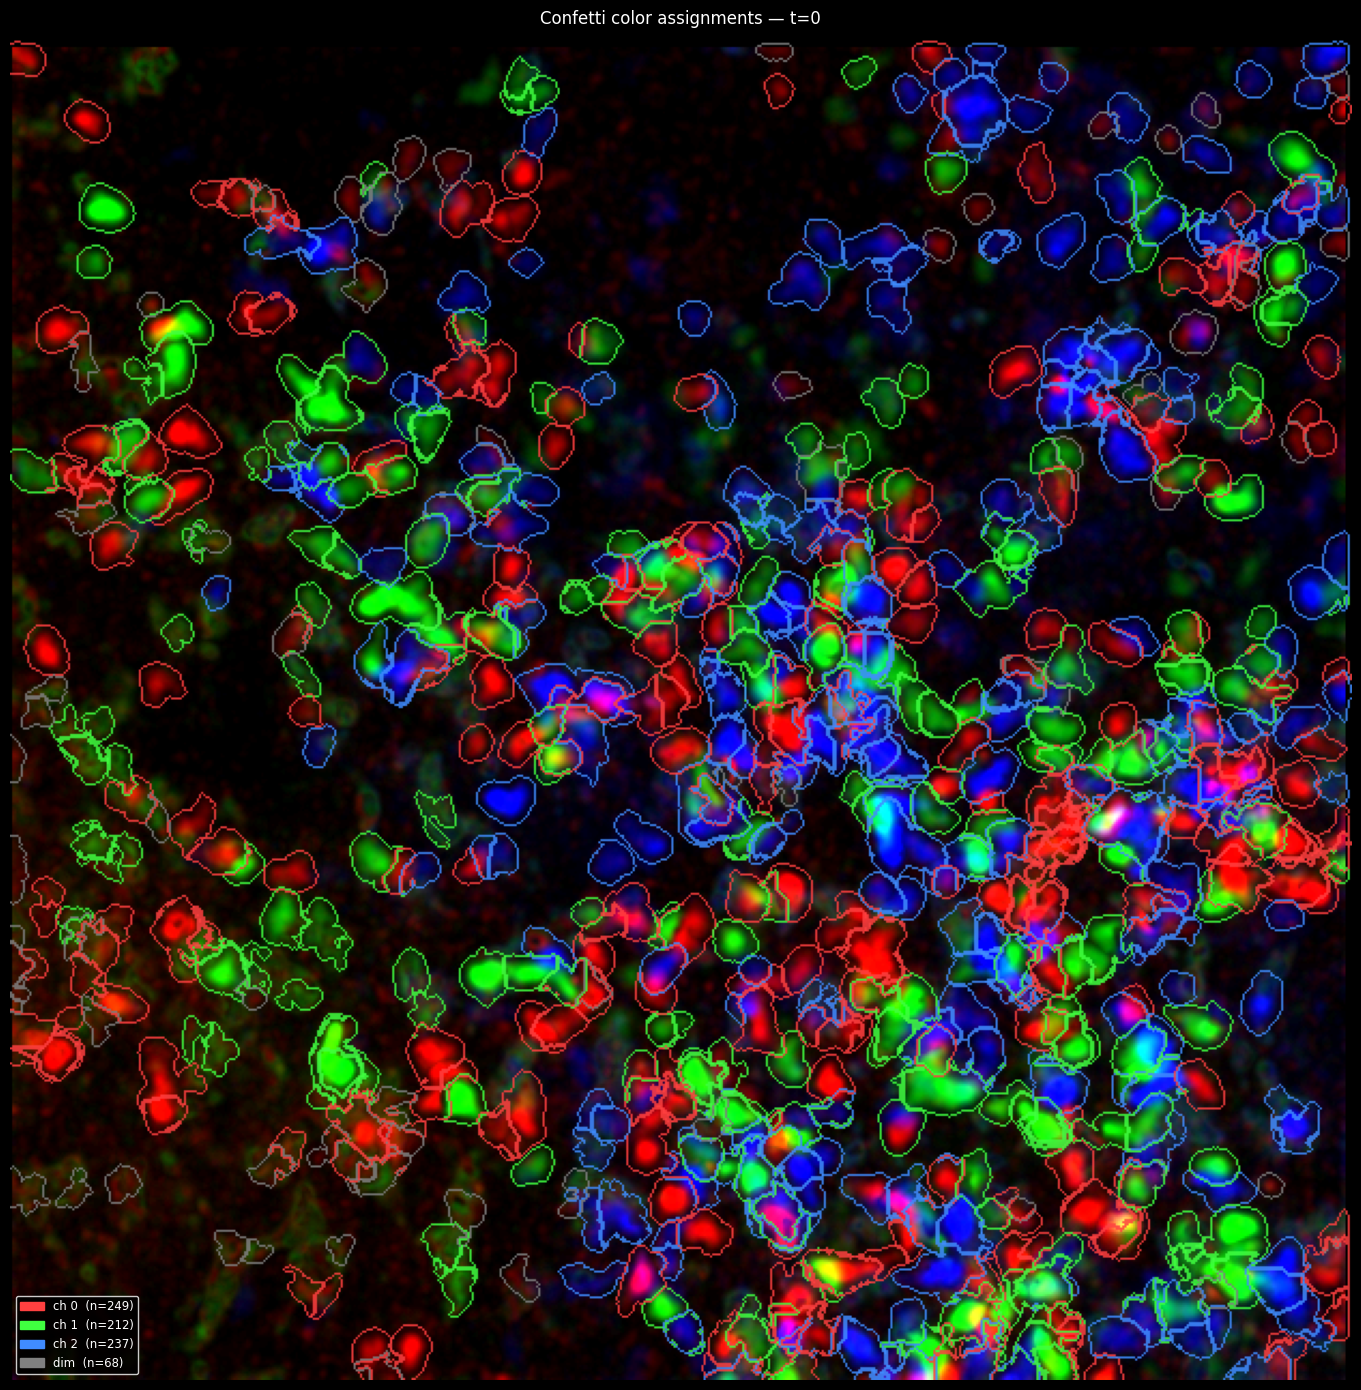

In [10]:
from skimage.segmentation import find_boundaries
from matplotlib.patches import Patch

CHANNEL_COLORS = {
    0: (1.0, 0.25, 0.25),
    1: (0.25, 1.0, 0.25),
    2: (0.25, 0.55, 1.0),
    3: (1.0, 0.85, 0.25),
}
DIM_COLOR = (0.5, 0.5, 0.5)
T_VIS = 0

def plot_color_assignments(instances_4d, vol_track, ch_indices, color_ids, t=0, figsize=(14, 14)):
    frame    = np.asarray(vol_track[t][ch_indices], dtype=np.float32)
    n_ch     = min(len(ch_indices), 3)
    proj     = frame[:n_ch].max(axis=1)
    seg_z    = instances_4d[t].max(axis=0)
    colors_t = color_ids.get(t, {})

    rgb = np.zeros((*proj.shape[1:], 3), dtype=np.float32)
    for ci in range(n_ch):
        lo, hi = float(np.percentile(proj[ci], 1)), float(np.percentile(proj[ci], 99))
        if hi > lo:
            rgb[..., ci] = np.clip((proj[ci] - lo) / (hi - lo), 0, 1)

    n_drawn = {k: 0 for k in list(CHANNEL_COLORS.keys()) + [-1]}
    for cid in np.unique(seg_z):
        if cid == 0:
            continue
        ch    = colors_t.get(int(cid), -1)
        color = np.array(CHANNEL_COLORS.get(ch, DIM_COLOR) if ch >= 0 else DIM_COLOR)
        bd    = find_boundaries(seg_z == cid, mode='outer')
        rgb[bd] = color * 0.85 + rgb[bd] * 0.15
        n_drawn[ch] = n_drawn.get(ch, 0) + 1

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')
    ax.imshow(rgb)

    legend_items = []
    for ci in range(n_ch):
        legend_items.append(Patch(color=CHANNEL_COLORS.get(ci, DIM_COLOR),
                                  label=f'ch {ci}  (n={n_drawn.get(ci, 0)})'))
    legend_items.append(Patch(color=DIM_COLOR, label=f'dim  (n={n_drawn.get(-1, 0)})'))
    leg = ax.legend(handles=legend_items, loc='lower left', fontsize='small', frameon=True)
    leg.get_frame().set_facecolor('black'); leg.get_frame().set_edgecolor('white')
    for txt in leg.get_texts(): txt.set_color('white')

    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'Confetti color assignments — t={t}', color='white')
    plt.tight_layout(); plt.show()

plot_color_assignments(instances_4d, vol_track, CH_INDICES, color_ids, t=T_VIS)

### 6b — Centroids, flows + patch extraction

In [15]:
import gc

centroids_all    = {}
intensities_all  = {}
cell_flows_all   = {}
int_patches_all  = {}
flow_patches_all = {}
grey_frames      = None   # kept only for uid_track (needed for cell-43 visualization)

PATCH_SIZE = 24
Z_CONTEXT  = 1   # centroid Z ± 1 → 3 slices, model input: [6, P, P]

for uid, inst in instances_per_uid.items():
    # Materialise zarr once per volume — ~600 MB per volume, deleted below
    vol_arr = np.asarray(volumes[uid][0])                               # [T, C, Z, H, W]
    centroids_all[uid]    = compute_3d_centroids(inst)
    intensities_all[uid]  = extract_cell_intensities(inst, vol_arr, ch_indices=CH_INDICES)
    grey = vol_arr[:, CH_INDICES].mean(axis=1).astype(np.float32)      # [T, Z, H, W]
    del vol_arr
    gc.collect()

    cell_flows_all[uid]   = compute_cell_flows(grey, inst, n_workers=8)
    int_patches_all[uid]  = extract_cell_patches(grey, centroids_all[uid],
                                                  patch_size=PATCH_SIZE, z_context=Z_CONTEXT, n_workers=8)
    flow_patches_all[uid] = compute_patch_metrics(grey, centroids_all[uid],
                                                   patch_size=PATCH_SIZE, z_context=Z_CONTEXT, n_workers=8)

    if uid == uid_track:
        grey_frames = grey   # keep for visualization (cell-43)
    del grey
    gc.collect()

    n_cells = sum(len(v) for v in centroids_all[uid].values())
    print(f"{uid}: {n_cells} total cells, "
          f"t=0 has {len(int_patches_all[uid].get(0, {}))} patches")

# Aliases for single-volume visualization and inference
centroids    = centroids_all[uid_track]
intensities  = intensities_all[uid_track]
cell_flows   = cell_flows_all[uid_track]
int_patches  = int_patches_all[uid_track]
flow_patches = flow_patches_all[uid_track]

n_total = sum(sum(len(v) for v in c.values()) for c in centroids_all.values())
print(f"\nTotal cells: {n_total} across {len(centroids_all)} volumes")
print(f"{uid_track}: {sum(len(v) for v in centroids.values())} cells  "
      f"| {len(list(intensities[0].values())[0])} confetti channels")

xh9GFi: 48167 total cells, t=0 has 775 patches
N0VlpP: 52663 total cells, t=0 has 860 patches
qcN9Br: 48674 total cells, t=0 has 771 patches
ENH3fS: 71620 total cells, t=0 has 1481 patches
uNTqPu: 49368 total cells, t=0 has 849 patches

Total cells: 270492 across 5 volumes
xh9GFi: 48167 cells  | 3 confetti channels


Anchor cell 1798 @ t=0
  All cells at t=1:                   723
  Within 16 µm (what model sees):  6
  positive (>0.8): 3   negative (<0.2): 1   ambiguous: 2
  Best positive:  cell 1267  target=1.00  dist=12.5 µm
  Worst negative: cell 1845  target=0.09  dist=12.3 µm


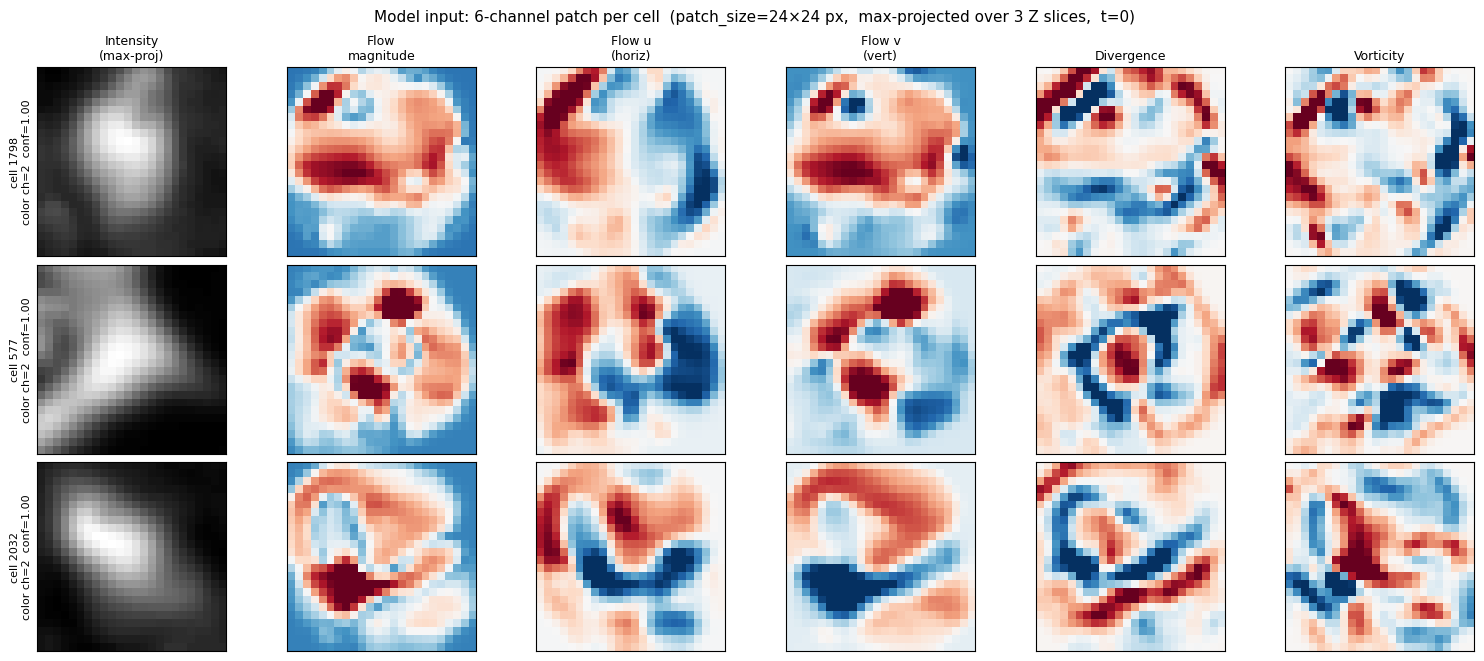

Ch 0  intensity:  z-score normalised max-projection — cell body brightness
Ch 1  magnitude:  how fast pixels move between this frame and the next
Ch 2–3  u / v:    direction of that motion (horizontal / vertical)
Ch 4–5  div/vort: local expansion-contraction and rotation in the flow


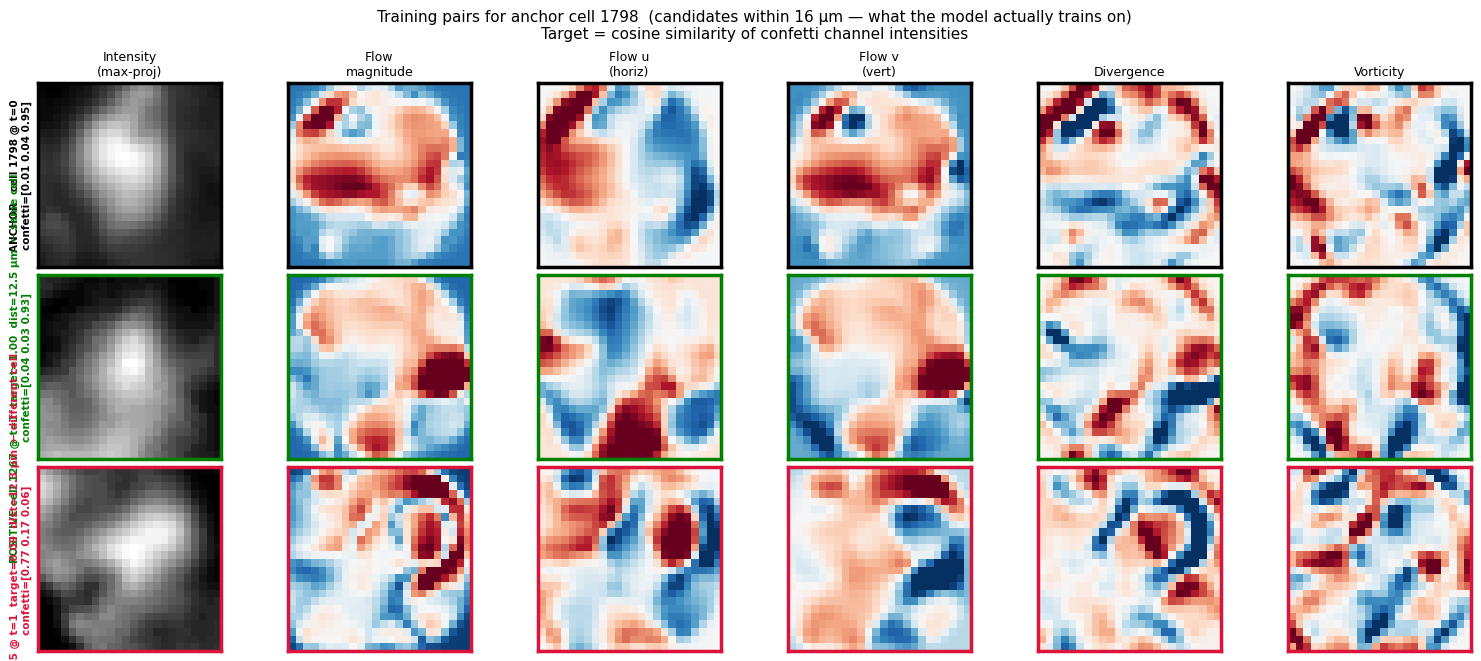

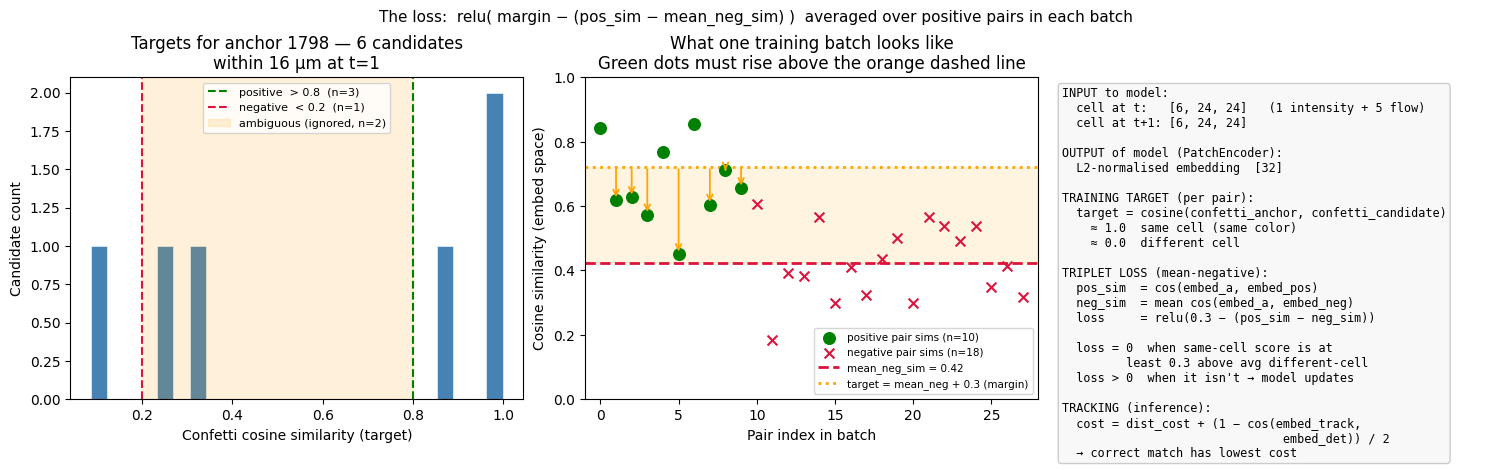

In [16]:
# =============================================================================
# VISUALISE: what goes into the model and what the loss is optimising
# Candidates filtered to search_radius_um — exactly what the model trains on.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

SEARCH_RADIUS_UM = 16   # must match train_patch_tracker call below

CH_NAMES = ['Intensity\n(max-proj)', 'Flow\nmagnitude',
            'Flow u\n(horiz)', 'Flow v\n(vert)', 'Divergence', 'Vorticity']
CMAPS    = ['gray', 'RdBu_r', 'RdBu_r', 'RdBu_r', 'RdBu_r', 'RdBu_r']
_scale   = np.array([pix_res_vol['z'], pix_res_vol['y'], pix_res_vol['x']], np.float32)

# ── helpers ───────────────────────────────────────────────────────────────────
def _get_input(t, cid):
    ip = int_patches.get(t, {}).get(cid)
    fp = flow_patches.get(t, {}).get(cid)
    if ip is None:
        return None
    P  = ip.shape[-1]
    fp = fp if fp is not None else np.zeros((5, P, P), np.float32)
    return np.concatenate([ip, fp], axis=0)

def _conf_cosine(cid_a, t_a, cid_b, t_b):
    va = intensities.get(t_a, {}).get(cid_a)
    vb = intensities.get(t_b, {}).get(cid_b)
    if va is None or vb is None:
        return float('nan')
    va = va.astype(np.float32); vb = vb.astype(np.float32)
    return float((va @ vb) / (np.linalg.norm(va) * np.linalg.norm(vb) + 1e-8))

def _dist_um(cid_a, t_a, cid_b, t_b):
    ca = centroids.get(t_a, {}).get(cid_a)
    cb = centroids.get(t_b, {}).get(cid_b)
    if ca is None or cb is None:
        return float('inf')
    return float(np.linalg.norm((ca - cb) * _scale))

# ── pick 3 bright cells at t=0 with patches + flow ───────────────────────────
T0 = 0
bright = {
    cid: float(intensities[T0][cid].max())
    for cid in int_patches.get(T0, {})
    if cid in flow_patches.get(T0, {}) and cid in intensities.get(T0, {})
}
top3 = sorted(bright, key=bright.get, reverse=True)[:3]

# ── candidates at t+1 within search radius of top3[0] ────────────────────────
T1         = T0 + 1
anchor_cid = top3[0]
anchor_pos = centroids[T0][anchor_cid] * _scale

# Filter to search radius — same logic as train_patch_tracker
cands_in_r = {
    cid: cid
    for cid in int_patches.get(T1, {})
    if cid in flow_patches.get(T1, {})
    and cid in intensities.get(T1, {})
    and cid in centroids.get(T1, {})
    and float(np.linalg.norm(centroids[T1][cid] * _scale - anchor_pos)) <= SEARCH_RADIUS_UM
}

tgts_in_r  = {cid: _conf_cosine(anchor_cid, T0, cid, T1) for cid in cands_in_r}
pos_cid    = max(tgts_in_r, key=tgts_in_r.get)
neg_cid    = min(tgts_in_r, key=tgts_in_r.get)
pos_target = tgts_in_r[pos_cid]
neg_target = tgts_in_r[neg_cid]

print(f"Anchor cell {anchor_cid} @ t={T0}")
print(f"  All cells at t={T1}:                   {len(int_patches.get(T1,{}))}")
print(f"  Within {SEARCH_RADIUS_UM} µm (what model sees):  {len(cands_in_r)}")
n_pos = sum(1 for v in tgts_in_r.values() if v > 0.8)
n_neg = sum(1 for v in tgts_in_r.values() if v < 0.2)
n_amb = len(cands_in_r) - n_pos - n_neg
print(f"  positive (>0.8): {n_pos}   negative (<0.2): {n_neg}   ambiguous: {n_amb}")
print(f"  Best positive:  cell {pos_cid}  target={pos_target:.2f}  "
      f"dist={_dist_um(anchor_cid, T0, pos_cid, T1):.1f} µm")
print(f"  Worst negative: cell {neg_cid}  target={neg_target:.2f}  "
      f"dist={_dist_um(anchor_cid, T0, neg_cid, T1):.1f} µm")

# =============================================================================
# Figure 1 — 3 example cells × 6 input channels
# =============================================================================
fig, axes = plt.subplots(3, 6, figsize=(15, 6.5), constrained_layout=True)
fig.suptitle(
    f'Model input: 6-channel patch per cell  '
    f'(patch_size={PATCH_SIZE}×{PATCH_SIZE} px,  '
    f'max-projected over {2*Z_CONTEXT+1} Z slices,  t={T0})',
    fontsize=11,
)
for row, cid in enumerate(top3):
    inp  = _get_input(T0, cid)
    conf = intensities[T0][cid]
    norm = conf / (np.linalg.norm(conf) + 1e-8)
    for col, (img, name, cmap) in enumerate(zip(inp, CH_NAMES, CMAPS)):
        ax = axes[row, col]
        ax.imshow(img, cmap=cmap, interpolation='nearest',
                  vmin=img.min() if col == 0 else -2.0,
                  vmax=img.max() if col == 0 else  2.0)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(name, fontsize=9)
    axes[row, 0].set_ylabel(
        f'cell {cid}\ncolor ch={int(conf.argmax())}  conf={norm.max():.2f}',
        fontsize=8,
    )
plt.show()
print("Ch 0  intensity:  z-score normalised max-projection — cell body brightness")
print("Ch 1  magnitude:  how fast pixels move between this frame and the next")
print("Ch 2–3  u / v:    direction of that motion (horizontal / vertical)")
print("Ch 4–5  div/vort: local expansion-contraction and rotation in the flow")

# =============================================================================
# Figure 2 — positive / negative pair (both within search radius)
# =============================================================================
fig, axes = plt.subplots(3, 6, figsize=(15, 6.5), constrained_layout=True)
fig.suptitle(
    f'Training pairs for anchor cell {anchor_cid}  '
    f'(candidates within {SEARCH_RADIUS_UM} µm — what the model actually trains on)\n'
    'Target = cosine similarity of confetti channel intensities',
    fontsize=11,
)
rows_data = [
    (_get_input(T0, anchor_cid), intensities[T0][anchor_cid],
     f'ANCHOR   cell {anchor_cid} @ t={T0}', 'black'),
    (_get_input(T1, pos_cid), intensities[T1][pos_cid],
     f'POSITIVE cell {pos_cid} @ t={T1}  '
     f'target={pos_target:.2f}  dist={_dist_um(anchor_cid,T0,pos_cid,T1):.1f} µm  ← same cell',
     'green'),
    (_get_input(T1, neg_cid), intensities[T1][neg_cid],
     f'NEGATIVE cell {neg_cid} @ t={T1}  '
     f'target={neg_target:.2f}  dist={_dist_um(anchor_cid,T0,neg_cid,T1):.1f} µm  ← different cell',
     'crimson'),
]
for row, (inp, conf, label, color) in enumerate(rows_data):
    norm = conf / (conf.sum() + 1e-8)
    for col, (img, name, cmap) in enumerate(zip(inp, CH_NAMES, CMAPS)):
        ax = axes[row, col]
        ax.imshow(img, cmap=cmap, interpolation='nearest',
                  vmin=img.min() if col == 0 else -2.0,
                  vmax=img.max() if col == 0 else  2.0)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_edgecolor(color); sp.set_linewidth(2.5)
        if row == 0:
            ax.set_title(name, fontsize=9)
    axes[row, 0].set_ylabel(
        f'{label}\nconfetti={np.round(norm, 2)}',
        fontsize=7.5, color=color, fontweight='bold',
    )
plt.show()

# =============================================================================
# Figure 3 — loss diagram (uses search-radius-filtered candidates)
# =============================================================================
MARGIN = 0.3

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
fig.suptitle(
    'The loss:  relu( margin − (pos_sim − mean_neg_sim) )  '
    'averaged over positive pairs in each batch',
    fontsize=11,
)

# (a) confetti target distribution — within search radius only
ax = axes[0]
all_tgt  = np.array(list(tgts_in_r.values()))
n_pos_   = (all_tgt > 0.8).sum()
n_neg_   = (all_tgt < 0.2).sum()
n_ambig_ = len(all_tgt) - n_pos_ - n_neg_

ax.hist(all_tgt, bins=25, color='steelblue', edgecolor='white', lw=0.4)
ymax = ax.get_ylim()[1]
ax.axvline(0.8, color='green',   ls='--', lw=1.5, label=f'positive  > 0.8  (n={n_pos_})')
ax.axvline(0.2, color='crimson', ls='--', lw=1.5, label=f'negative  < 0.2  (n={n_neg_})')
ax.fill_betweenx([0, ymax], 0.2, 0.8, color='orange', alpha=0.15,
                 label=f'ambiguous (ignored, n={n_ambig_})')
ax.set_ylim(0, ymax)
ax.set_xlabel('Confetti cosine similarity (target)')
ax.set_ylabel('Candidate count')
ax.set_title(f'Targets for anchor {anchor_cid} — {len(cands_in_r)} candidates\n'
             f'within {SEARCH_RADIUS_UM} µm at t={T1}')
ax.legend(fontsize=8)

# (b) schematic: positive sims vs mean negative in one batch
ax = axes[1]
np.random.seed(1)
n_p, n_n = 10, 18
p_ex   = np.random.normal(0.68, 0.10, n_p).clip(0.2, 0.99)
n_ex   = np.random.normal(0.43, 0.12, n_n).clip(0.0, 0.85)
mean_n = n_ex.mean()

ax.scatter(range(n_p), p_ex, color='green', s=70, zorder=3,
           label=f'positive pair sims (n={n_p})')
ax.scatter(range(n_p, n_p + n_n), n_ex, color='crimson', marker='x', s=50, zorder=3,
           label=f'negative pair sims (n={n_n})')
ax.axhline(mean_n, color='crimson', ls='--', lw=2.0,
           label=f'mean_neg_sim = {mean_n:.2f}')
ax.axhline(mean_n + MARGIN, color='orange', ls=':', lw=2.0,
           label=f'target = mean_neg + {MARGIN} (margin)')
ax.fill_between([-1, n_p + n_n], mean_n, mean_n + MARGIN, color='orange', alpha=0.12)
for x, ps in enumerate(p_ex):
    if ps < mean_n + MARGIN:
        ax.annotate('', xy=(x, ps), xytext=(x, mean_n + MARGIN),
                    arrowprops=dict(arrowstyle='->', color='orange', lw=1.3))
ax.set_xlim(-1, n_p + n_n); ax.set_ylim(0, 1)
ax.set_xlabel('Pair index in batch')
ax.set_ylabel('Cosine similarity (embed space)')
ax.set_title('What one training batch looks like\n'
             'Green dots must rise above the orange dashed line')
ax.legend(fontsize=7.5, loc='lower right')

# (c) formula
ax = axes[2]
ax.axis('off')
lines = [
    "INPUT to model:",
    f"  cell at t:   [6, {PATCH_SIZE}, {PATCH_SIZE}]   (1 intensity + 5 flow)",
    f"  cell at t+1: [6, {PATCH_SIZE}, {PATCH_SIZE}]",
    "",
    "OUTPUT of model (PatchEncoder):",
    "  L2-normalised embedding  [32]",
    "",
    "TRAINING TARGET (per pair):",
    "  target = cosine(confetti_anchor, confetti_candidate)",
    "    ≈ 1.0  same cell (same color)",
    "    ≈ 0.0  different cell",
    "",
    "TRIPLET LOSS (mean-negative):",
    "  pos_sim  = cos(embed_a, embed_pos)",
    "  neg_sim  = mean cos(embed_a, embed_neg)",
    f"  loss     = relu({MARGIN} − (pos_sim − neg_sim))",
    "",
    "  loss = 0  when same-cell score is at",
    f"         least {MARGIN} above avg different-cell",
    "  loss > 0  when it isn't → model updates",
    "",
    "TRACKING (inference):",
    "  cost = dist_cost + (1 − cos(embed_track,",
    "                               embed_det)) / 2",
    "  → correct match has lowest cost",
]
ax.text(0.03, 0.97, '\n'.join(lines), transform=ax.transAxes,
        fontsize=8.5, fontfamily='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#f8f8f8', edgecolor='#cccccc'))

plt.show()

Landing zone  (anchor 1798 @ t=0 → t=1)
  Flow:      u=+0.3px (+0.1µm X)  v=+5.0px (+2.4µm Y)
  Residual:  7.4 µm  (landing → positive)  vs  naive 5.0 µm  (anchor → positive, no flow)
  Population (n=750 pairs):  naive med=6.8µm  landing med=5.8µm  improvement=+0.9µm
  Fraction where landing is closer than naive: 63%
  Positives within landing zone (16.0µm): 715/750 = 95%


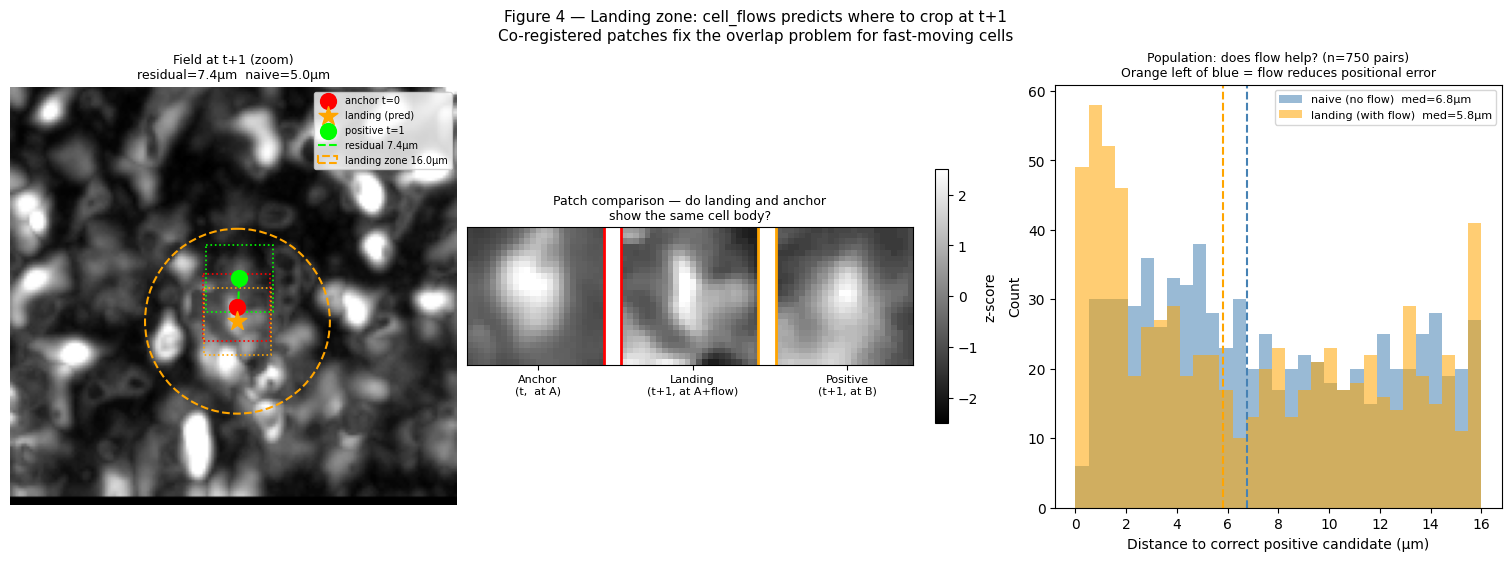

In [17]:
# =============================================================================
# VISUALISE: Landing zone concept
#
# Current approach: anchor patch centred at A (t), candidate patch centred at B (t+1).
#   Problem: if the cell moves > patch_radius, A and B don't overlap → the model
#   compares two non-overlapping crops and has to guess identity from background.
#
# Landing-zone approach: use cell_flows[T0][anchor] to predict landing position
#   L = A + flow.  Extract the t+1 patch centred at L instead of at B.
#   Now BOTH patches cover the same spatial neighbourhood → genuine overlap.
#   Residual = |L - B|  measures how accurate the flow prediction is.
#
# Figure 4 shows:
#   (a) Spatial crop: anchor (red), flow arrow, landing zone (orange *), positive (green)
#   (b) 3 patches side-by-side: anchor | landing | positive
#   (c) Population histogram: naive distance vs landing residual across all pairs
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

_pix = np.array([pix_res_vol['z'], pix_res_vol['y'], pix_res_vol['x']], np.float32)

LANDING_RADIUS_UM = 16.0   # µm — radius around anchor+flow to search for positive
flow_uv = cell_flows.get(T0, {}).get(anchor_cid)
if flow_uv is None:
    print("No cell_flows entry for anchor — re-run compute_cell_flows first")
else:
    anchor_zyx  = centroids[T0][anchor_cid]                                # [z,y,x] voxels
    landing_zyx = anchor_zyx + np.array([0., float(flow_uv[1]), float(flow_uv[0])])
    anchor_um   = anchor_zyx  * _pix
    landing_um  = landing_zyx * _pix
    pos_um      = centroids[T1][pos_cid] * _pix

    residual_um   = float(np.linalg.norm(landing_um[1:] - pos_um[1:]))   # XY only
    naive_dist_um = float(np.linalg.norm(anchor_um[1:]  - pos_um[1:]))

    # ── extract landing-zone patch from grey_frames[T1] ──────────────────────
    Z_d, H_, W_ = grey_frames.shape[1:]
    p  = PATCH_SIZE // 2
    lz = int(np.clip(round(landing_zyx[0]), 0, Z_d - 1))
    ly = int(round(landing_zyx[1]))
    lx = int(round(landing_zyx[2]))

    def _patch_at(frame_vol, z_c, y_c, x_c):
        """Max-Z-projected, z-score-normalised crop centred at (z_c, y_c, x_c)."""
        slices = []
        for dz in range(-Z_CONTEXT, Z_CONTEXT + 1):
            zi  = int(np.clip(z_c + dz, 0, Z_d - 1))
            f   = frame_vol[zi].astype(np.float32)
            y0  = y_c - p;  y1 = y_c + p + (PATCH_SIZE % 2)
            x0  = x_c - p;  x1 = x_c + p + (PATCH_SIZE % 2)
            pt  = max(0, -y0);  pb = max(0, y1 - H_)
            pl  = max(0, -x0);  pr = max(0, x1 - W_)
            crop = f[max(0,y0):min(H_,y1), max(0,x0):min(W_,x1)]
            if pt or pb or pl or pr:
                crop = np.pad(crop, ((pt,pb),(pl,pr)), mode='reflect')
            slices.append(crop)
        proj = np.stack(slices).max(axis=0)
        mu, sig = float(proj.mean()), float(proj.std())
        return (proj - mu) / (sig + 1e-6)

    grey_t1  = grey_frames[T1].astype(np.float32)
    land_pat = _patch_at(grey_t1, lz, ly, lx)
    anch_pat = int_patches[T0][anchor_cid][0]     # already extracted
    pos_pat  = int_patches[T1][pos_cid][0]

    # ── population residuals: landing vs naive for all anchor-positive pairs ─
    t0_cids  = [c for c in centroids.get(T0,{})
                if c in intensities.get(T0,{}) and c in cell_flows.get(T0,{})]
    t1_cids  = [c for c in centroids.get(T1,{}) if c in intensities.get(T1,{})]

    t0_pos   = np.stack([centroids[T0][c]*_pix for c in t0_cids])    # [N0,3]
    t1_pos   = np.stack([centroids[T1][c]*_pix for c in t1_cids])    # [N1,3]
    t0_flows = np.array([[cell_flows[T0][c][0], cell_flows[T0][c][1]]
                         for c in t0_cids], np.float32)               # [N0,2] u,v
    land_pos = t0_pos.copy()
    land_pos[:,2] += t0_flows[:,0] * _pix[2]   # u → X
    land_pos[:,1] += t0_flows[:,1] * _pix[1]   # v → Y

    t0_conf = np.stack([intensities[T0][c].astype(np.float32) for c in t0_cids])
    t1_conf = np.stack([intensities[T1][c].astype(np.float32) for c in t1_cids])
    t0_conf /= np.linalg.norm(t0_conf, axis=1, keepdims=True) + 1e-8
    t1_conf /= np.linalg.norm(t1_conf, axis=1, keepdims=True) + 1e-8

    # XY pairwise distance [N0, N1]
    xy_dist = np.sqrt(((t0_pos[:,None,1:] - t1_pos[None,:,1:])**2).sum(2))

    pop_res, pop_naive = [], []
    for i in range(len(t0_cids)):
        in_r = np.where(xy_dist[i] <= SEARCH_RADIUS_UM)[0]
        if not len(in_r):
            continue
        sims  = t0_conf[i] @ t1_conf[in_r].T
        best  = in_r[sims.argmax()]
        if sims.max() > 0.8:
            pop_naive.append(float(xy_dist[i, best]))
            pop_res.append(float(np.sqrt(((land_pos[i,1:] - t1_pos[best,1:])**2).sum())))

    pop_res   = np.array(pop_res)
    pop_naive = np.array(pop_naive)

    print(f"Landing zone  (anchor {anchor_cid} @ t={T0} → t={T1})")
    print(f"  Flow:      u={float(flow_uv[0]):+.1f}px ({float(flow_uv[0])*pix_res_vol['x']:+.1f}µm X)  "
          f"v={float(flow_uv[1]):+.1f}px ({float(flow_uv[1])*pix_res_vol['y']:+.1f}µm Y)")
    print(f"  Residual:  {residual_um:.1f} µm  (landing → positive)  "
          f"vs  naive {naive_dist_um:.1f} µm  (anchor → positive, no flow)")
    if len(pop_res):
        improvement = float(np.median(pop_naive) - np.median(pop_res))
        print(f"  Population (n={len(pop_res)} pairs):  "
              f"naive med={np.median(pop_naive):.1f}µm  landing med={np.median(pop_res):.1f}µm  "
              f"improvement={improvement:+.1f}µm")
        print(f"  Fraction where landing is closer than naive: "
              f"{100*(pop_res < pop_naive).mean():.0f}%")
        n_in = int((pop_res <= LANDING_RADIUS_UM).sum())
        print(f"  Positives within landing zone ({LANDING_RADIUS_UM}µm): {n_in}/{len(pop_res)} = {100*n_in/len(pop_res):.0f}%")

    # ── Figure 4 ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), constrained_layout=True)
    fig.suptitle(
        'Figure 4 — Landing zone: cell_flows predicts where to crop at t+1\n'
        'Co-registered patches fix the overlap problem for fast-moving cells',
        fontsize=11,
    )

    # (a) Spatial crop: anchor, flow arrow, landing, positive, residual
    ax = axes[0]
    field_n = grey_t1.max(axis=0).astype(np.float32)
    lo, hi  = float(np.percentile(field_n, 1)), float(np.percentile(field_n, 99))
    field_n = np.clip((field_n - lo) / (hi - lo + 1e-5), 0, 1)

    cy_mid  = int((anchor_zyx[1] + landing_zyx[1]) / 2)
    cx_mid  = int((anchor_zyx[2] + landing_zyx[2]) / 2)
    hw      = max(PATCH_SIZE * 2, 80)
    ry0 = max(0, cy_mid - hw);  ry1 = min(H_, cy_mid + hw)
    rx0 = max(0, cx_mid - hw);  rx1 = min(W_, cx_mid + hw)

    ax.imshow(field_n[ry0:ry1, rx0:rx1], cmap='gray', origin='upper')

    def _disp(zyx):
        return float(zyx[2]) - rx0, float(zyx[1]) - ry0   # (col, row) for scatter

    ax_c, ax_r = _disp(anchor_zyx)
    lx_c, lx_r = _disp(landing_zyx)
    px_c, px_r = float(centroids[T1][pos_cid][2]) - rx0, float(centroids[T1][pos_cid][1]) - ry0

    ax.scatter(ax_c, ax_r, c='red',    s=130, zorder=5, marker='o', label=f'anchor t={T0}')
    ax.annotate('', xy=(lx_c, lx_r), xytext=(ax_c, ax_r),
                arrowprops=dict(arrowstyle='->', color='orange', lw=2.5))
    ax.scatter(lx_c, lx_r, c='orange', s=200, zorder=5, marker='*', label='landing (pred)')
    ax.scatter(px_c, px_r, c='lime',   s=130, zorder=5, marker='o', label=f'positive t={T1}')
    ax.plot([lx_c, px_c], [lx_r, px_r], color='lime', ls='--', lw=1.5,
            label=f'residual {residual_um:.1f}µm')
    circ = plt.Circle((lx_c, lx_r), LANDING_RADIUS_UM / pix_res_vol['y'],
                       edgecolor='orange', facecolor='none', lw=1.5, ls='--',
                       label=f'landing zone {LANDING_RADIUS_UM}µm')
    ax.add_patch(circ)
    # patch footprints
    for cx, cy, col in [(ax_c, ax_r, 'red'), (lx_c, lx_r, 'orange'), (px_c, px_r, 'lime')]:
        rect = plt.Rectangle((cx - p, cy - p), PATCH_SIZE, PATCH_SIZE,
                              edgecolor=col, facecolor='none', lw=1.2, ls=':')
        ax.add_patch(rect)

    ax.legend(fontsize=7, loc='upper right')
    ax.set_title(f'Field at t+1 (zoom)\nresidual={residual_um:.1f}µm  naive={naive_dist_um:.1f}µm',
                 fontsize=9)
    ax.axis('off')

    # (b) 3 patches: anchor | landing | positive
    ax = axes[1]
    gap = 3
    P   = PATCH_SIZE
    canvas = np.full((P, 3*P + 2*gap), np.nan)
    canvas[:, :P]                = anch_pat
    canvas[:, P+gap:2*P+gap]     = land_pat
    canvas[:, 2*(P+gap):]        = pos_pat
    vmax = 2.5
    im = ax.imshow(canvas, cmap='gray', interpolation='nearest', vmin=-vmax, vmax=vmax)
    for xv, col in [(P - 0.5, 'red'), (P + gap - 0.5, 'red'),
                    (P + gap + P - 0.5, 'orange'), (2*P + 2*gap - 0.5, 'orange')]:
        ax.axvline(xv, color=col, lw=2)
    ax.set_xticks([P//2, P + gap + P//2, 2*(P+gap) + P//2])
    ax.set_xticklabels(['Anchor\n(t,  at A)', 'Landing\n(t+1, at A+flow)', 'Positive\n(t+1, at B)'],
                       fontsize=8)
    ax.set_yticks([])
    ax.set_title('Patch comparison — do landing and anchor\nshow the same cell body?', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.04, shrink=0.6, label='z-score')

    # (c) population residual histogram
    ax = axes[2]
    if len(pop_res):
        bins = np.linspace(0, SEARCH_RADIUS_UM, 32)
        ax.hist(np.clip(pop_naive, 0, SEARCH_RADIUS_UM), bins=bins, alpha=0.55,
                color='steelblue', label=f'naive (no flow)  med={np.median(pop_naive):.1f}µm')
        ax.hist(np.clip(pop_res,   0, SEARCH_RADIUS_UM), bins=bins, alpha=0.55,
                color='orange',    label=f'landing (with flow)  med={np.median(pop_res):.1f}µm')
        ax.axvline(np.median(pop_naive), color='steelblue', ls='--', lw=1.5)
        ax.axvline(np.median(pop_res),   color='orange',    ls='--', lw=1.5)
        ax.set_xlabel('Distance to correct positive candidate (µm)')
        ax.set_ylabel('Count')
        ax.set_title(f'Population: does flow help? (n={len(pop_res)} pairs)\n'
                     f'Orange left of blue = flow reduces positional error', fontsize=9)
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'No anchor-positive pairs found\n(check dim_quantile)',
                ha='center', va='center', transform=ax.transAxes)

    plt.show()


In [56]:
tracker, history = train_patch_tracker(
    intensity_patches_per_movie = list(int_patches_all.values()),
    metric_patches_per_movie    = list(flow_patches_all.values()),
    intensities_per_movie       = list(intensities_all.values()),
    centroids_per_movie         = list(centroids_all.values()),
    pix_res_per_movie           = [pix_res[uid] for uid in instances_per_uid],
    cell_flows_per_movie        = list(cell_flows_all.values()),
    embed_dim         = 32,
    search_radius_um  = 16,
    landing_radius_um = 16.0,
    lambda_consist    = 0.0,   # 0 = baseline (original loss); increase only once baseline converges
    batch_size        = 512,
    n_epochs          = 80,
    p_drop            = 0.5,
    margin            = 0.3,
    hard_neg_k        = 5,
    device            = 'cuda' if torch.cuda.is_available() else 'cpu',
)


PatchTracker: 56,309 pairs  (30,801 same-color / 25,508 different-color)  input=6ch × 24×24  embed_dim=32
  Epoch   1/80 | loss=0.3020  lr=1.00e-03
  Epoch  10/80 | loss=0.3000  lr=9.62e-04
  Epoch  20/80 | loss=0.3000  lr=8.55e-04
  Epoch  30/80 | loss=0.3000  lr=6.94e-04
  Epoch  40/80 | loss=0.3000  lr=5.05e-04
  Epoch  50/80 | loss=0.3000  lr=3.16e-04
  Epoch  60/80 | loss=0.3000  lr=1.55e-04
  Epoch  70/80 | loss=0.3000  lr=4.77e-05
  Epoch  80/80 | loss=0.3000  lr=1.00e-05


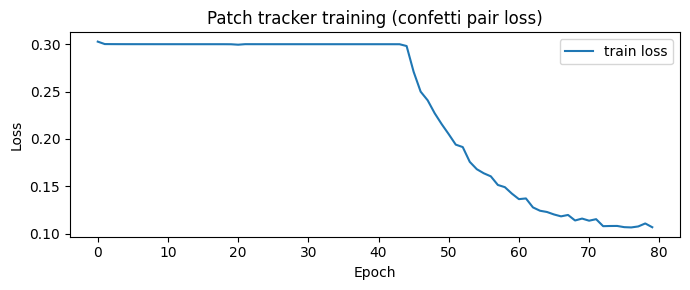

In [39]:
plt.figure(figsize=(7, 3))
plt.plot(history, label='train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Patch tracker training (confetti pair loss)')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
save_patch_tracker(
    tracker,
    "/home/dominik/Downloads/TMP/patch_tracker.pt",
    meta={"patch_size": PATCH_SIZE, "z_context": Z_CONTEXT, "embed_dim": 32, "pix_res": pix_res_vol},
)

PatchEncoder saved → /home/dominik/Downloads/TMP/patch_tracker.pt


In [18]:
# Load a previously saved patch tracker (skip training)
tracker, meta = load_patch_tracker(
    "/home/dominik/Downloads/TMP/patch_tracker.pt",
    device='cuda' if torch.cuda.is_available() else 'cpu',
)
PATCH_SIZE  = meta.get('patch_size', 32)
Z_CONTEXT   = meta.get('z_context',  1)
pix_res_vol = meta.get('pix_res',    pix_res_vol)
print(f"Loaded tracker  embed_dim={tracker.embed_dim}  patch_size={PATCH_SIZE}  z_context={Z_CONTEXT}")


Loaded tracker  embed_dim=32  patch_size=24  z_context=1


In [40]:
# Free multi-volume training data — only uid_track aliases are needed for inference below
import gc
for uid in list(instances_per_uid.keys()):
    if uid != uid_track:
        int_patches_all.pop(uid, None)
        flow_patches_all.pop(uid, None)
        cell_flows_all.pop(uid, None)
        centroids_all.pop(uid, None)
        intensities_all.pop(uid, None)
gc.collect()
print("Training data freed for non-tracking volumes")

Training data freed for non-tracking volumes


### 6d — Inference

In [41]:
embeddings = embed_cell_patches(
    tracker,
    int_patches,
    flow_patches,
    device = 'cuda' if torch.cuda.is_available() else 'cpu',
)
print(f"Embeddings: {len(embeddings)} timepoints, "
      f"dim={next(iter(embeddings[0].values())).shape[0]}")


Embeddings: 61 timepoints, dim=32


In [ ]:
import itertools, io, contextlib
import matplotlib.pyplot as plt
import pandas as pd

# ── Sweep ─────────────────────────────────────────────────────────────────────

def sweep_track_sequence(param_grid, fixed=None):
    """Run track_sequence for every combination in param_grid. Returns all rows as a list of dicts."""
    base = dict(
        model=None, morphology=None,
        instances_4d=instances_4d,
        pix_res=pix_res_vol,
        cell_flows=cell_flows,
        cell_embeddings=embeddings,
        device='cuda',
    )
    if fixed:
        base.update(fixed)

    keys   = list(param_grid.keys())
    combos = list(itertools.product(*param_grid.values()))
    print(f"Sweeping {len(combos)} combinations…\n")

    rows = []
    for i, combo in enumerate(combos, 1):
        params = dict(zip(keys, combo))
        with contextlib.redirect_stdout(io.StringIO()):
            tracks = track_sequence(**base, **params)
            sc     = score_tracking(
                tracks, instances_4d, vol_track,
                ch_indices=CH_INDICES, pix_res=pix_res_vol, verbose=False,
            )
        lens = [len(v) for v in tracks.values()]
        row  = {
            **params,
            'n_tracks':   len(tracks),
            'median_len': int(np.median(lens)),
            'mean_len':   round(float(np.mean(lens)), 1),
            'continuity': round(sc['continuity']['mean'], 4),
            'switch_rate':round(sc['color_switch_rate'], 4),
            'seg_len':    round(sc['mean_segment_length'], 2),
        }
        rows.append(row)
        print(f"  {i:3d}/{len(combos)}  {params}  "
              f"cont={row['continuity']:.3f}  sw={row['switch_rate']:.3f}  "
              f"med={row['median_len']}  mean={row['mean_len']}")
    return rows


# ── Heatmaps ──────────────────────────────────────────────────────────────────

def plot_sweep_heatmaps(rows, param_keys, metrics=None, agg='mean'):
    """2D heatmap for every parameter pair × metric. Other params are aggregated (default: mean).

    Green = good, red = bad for each metric direction.
    """
    if metrics is None:
        metrics = ['continuity', 'switch_rate', 'mean_len']

    df     = pd.DataFrame(rows)
    pairs  = list(itertools.combinations(param_keys, 2))
    n_met  = len(metrics)
    n_pair = len(pairs)
    good_high = {'continuity', 'mean_len', 'median_len', 'seg_len'}

    fig, axes = plt.subplots(n_met, n_pair,
                             figsize=(3.6 * n_pair, 3.2 * n_met),
                             squeeze=False)

    for ci, (p1, p2) in enumerate(pairs):
        for ri, metric in enumerate(metrics):
            ax    = axes[ri, ci]
            pivot = df.groupby([p1, p2])[metric].agg(agg).unstack(p2)
            cmap  = 'RdYlGn' if metric in good_high else 'RdYlGn_r'
            vmin, vmax = pivot.values.min(), pivot.values.max()
            im = ax.imshow(pivot.values, cmap=cmap, aspect='auto',
                           vmin=vmin, vmax=vmax)
            plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02)

            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels([str(v) for v in pivot.columns], fontsize=7)
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels([str(v) for v in pivot.index], fontsize=7)
            ax.set_xlabel(p2, fontsize=8)

            for ii in range(pivot.shape[0]):
                for jj in range(pivot.shape[1]):
                    ax.text(jj, ii, f'{pivot.values[ii, jj]:.3f}',
                            ha='center', va='center', fontsize=6.5)

            if ri == 0:
                ax.set_title(f'{p1} × {p2}', fontsize=8, fontweight='bold')
            ax.set_ylabel((f'{metric}\n' if ci == 0 else '') + p1, fontsize=8)

    plt.suptitle(
        f'Parameter sweep heatmaps  (cell value = {agg} over other params)  |  green=better',
        fontsize=10, y=1.01,
    )
    plt.tight_layout()
    plt.show()


# ── Multi-metric ranking table ────────────────────────────────────────────────

def print_sweep_ranking(rows, param_keys, top_n=10):
    """Print top-N per metric + a combined score ranking.

    Combined score: normalises each metric to [0,1] (flipped so higher=better),
    then averages with equal weight.
    """
    df        = pd.DataFrame(rows)
    metrics   = ['continuity', 'switch_rate', 'mean_len', 'seg_len']
    good_high = {'continuity', 'mean_len', 'median_len', 'seg_len'}
    all_cols  = param_keys + ['n_tracks', 'median_len', 'mean_len',
                               'continuity', 'switch_rate', 'seg_len', 'score']

    # Build combined score
    norm = df[metrics].copy()
    for m in metrics:
        lo, hi = df[m].min(), df[m].max()
        if hi > lo:
            norm[m] = (df[m] - lo) / (hi - lo)
            if m not in good_high:
                norm[m] = 1 - norm[m]
        else:
            norm[m] = 0.5
    df['score'] = norm.mean(axis=1).round(4)

    def _table(subset, title):
        print(f'\n── {title} ──')
        widths = {c: max(len(c), max(len(str(v)) for v in subset[c].astype(str)))
                  for c in all_cols}
        sep    = '  '
        header = sep.join(c.ljust(widths[c]) for c in all_cols)
        print(header)
        print('─' * len(header))
        for _, r in subset.iterrows():
            print(sep.join(str(r[c]).ljust(widths[c]) for c in all_cols))

    for metric in metrics:
        asc = metric not in good_high
        _table(
            df.sort_values(metric, ascending=asc).head(top_n),
            f'Top {top_n} by {metric}  ({"↓ lower=better" if asc else "↑ higher=better"})',
        )

    _table(
        df.sort_values('score', ascending=False).head(top_n),
        f'Top {top_n} by combined score  (equal-weight: ↑continuity + ↓switch_rate + ↑mean_len + ↑seg_len)',
    )


# ── Run ───────────────────────────────────────────────────────────────────────

fixed = dict(
    search_radius_um    = 16,
    n_hist              = 5,
    momentum_decay      = 0.8,
    w_collective        = 0.0,
    w_breadcrumb        = 0.0,
    exclusion_radius_um = 12.0,
)

param_grid = dict(
    max_gap       = [1, 3],
    max_cost      = [1.0, 1.2],
    w_persistence = [0.0],
    w_exclusion   = [0.0, 0.2, 0.4, 0.8],
)

sweep_rows = sweep_track_sequence(param_grid, fixed=fixed)

plot_sweep_heatmaps(
    sweep_rows,
    param_keys=list(param_grid.keys()),
    metrics=['continuity', 'switch_rate', 'mean_len'],
    agg='mean',
)

print_sweep_ranking(sweep_rows, param_keys=list(param_grid.keys()), top_n=10)


In [52]:
tracks_pred = track_sequence(
    model            = None,
    instances_4d     = instances_4d,
    morphology       = None,
    pix_res          = pix_res_vol,
    cell_flows       = cell_flows,
    cell_embeddings  = embeddings,
    max_cost         = 1.2,
    n_hist           = 5,
    momentum_decay   = 0.8,
    max_gap          = 1,
    w_collective     = 0.0,
    w_breadcrumb     = 0.0,
    w_persistence    = 0.0,
    w_exclusion      = 0.0,
    # Kalman filter
    process_noise    = 1.0,   # µm²/frame — how fast velocity can change
    obs_noise        = 9.0,   # µm² — centroid localisation uncertainty
    chi2_gate        = 4.6,  # chi²₃ p=0.99 Mahalanobis gate
    # Embedding EMA
    w_app            = 1.0,   # embedding weight (0 = pure Kalman distance)
    emb_momentum     = 0.8,   # EMA decay for track embedding
)

print(f"Tracks: {len(tracks_pred)}")
lens = [len(v) for v in tracks_pred.values()]
print(f"Length: min={min(lens)}  median={int(np.median(lens))}  max={max(lens)}")

track_sequence: 6471 tracks over 61 frames
Tracks: 6471
Length: min=1  median=5  max=54


In [22]:
# Ablation: embeddings vs no embeddings
# Tests whether cell_embeddings actually contribute signal to the cost matrix.
# If metrics match the baseline (with embeddings), app_cost ≈ 0.5 everywhere
# (constant offset) and embeddings add compute but no discriminative signal.
tracks_no_emb = track_sequence(
    model            = None,
    instances_4d     = instances_4d,
    morphology       = None,
    pix_res          = pix_res_vol,
    cell_flows       = cell_flows,
    cell_embeddings  = None,          # <-- disabled
    search_radius_um = 16,
    max_cost         = 1.2,
    n_hist           = 5,
    momentum_decay   = 0.8,
    max_gap          = 3,
    w_collective     = 0.0,
    w_breadcrumb     = 0.0,
    w_persistence    = 0.0,
    w_exclusion      = 0.0,
)
sc_no_emb = score_tracking(
    tracks_no_emb, instances_4d, vol_track,
    ch_indices=CH_INDICES, pix_res=pix_res_vol, verbose=True,
)
lens_no_emb = [len(v) for v in tracks_no_emb.values()]
print(f"\n── No embeddings ──")
print(f"  n_tracks   : {len(tracks_no_emb)}")
print(f"  median_len : {int(np.median(lens_no_emb))}")
print(f"  mean_len   : {np.mean(lens_no_emb):.1f}")
print(f"  continuity : {sc_no_emb['continuity']['mean']:.4f}")
print(f"  switch_rate: {sc_no_emb['color_switch_rate']:.4f}")
print(f"  seg_len    : {sc_no_emb['mean_segment_length']:.2f}")
print(f"\n── Baseline (with embeddings) ──")
print(f"  n_tracks   : 3552  continuity: 0.7976  switch_rate: 0.2231")


track_sequence: 2561 tracks over 61 frames
Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
--- Track length distribution (2561 tracks, 61 frames) ---
  min=1  p25=5  median=13  p75=29  max=61  mean=18.8
  full-length (61 frames): 2 tracks  (0%)

--- Frame-to-frame continuity (track fragmentation) ---
  mean=0.836  min=0.792  max=0.894
  Fraction of active tracks that survive each consecutive frame pair.
  1.0 = no breaks, ~0.8 = 20% of tracks re-initialise each frame.

--- Color-switch rate (within-segment identity) ---
  rate=0.2469  (10101 switches / 40907 transitions across 2226 tracks)
  mean correct-segment length: 4.3 frames  (longer = better; 1/switch_rate ≈ 4.0)

── No embeddings ──
  n_tracks   : 2561
  median_len : 13
  mean_len   : 18.8
  continuity : 0.8357
  switch_rate: 0.2469
  seg_len    : 4.34

── Baseline (with embeddings) ──
  n_tracks   : 3552  continuity: 0.7976  switch_rate: 0.2231


### 6e — Scoring & visualization

In [53]:
# Score tracking quality: color-switch rate + fragmentation + track length stats.
results_tracking = score_tracking(
    tracks_pred,
    instances_4d,
    vol_track,
    ch_indices = CH_INDICES,
    pix_res    = pix_res_vol,
    verbose    = True,
)

Color assignment: 4817 dim cells excluded (dim_quantile=0.1, threshold=9.2034)
--- Track length distribution (6471 tracks, 61 frames) ---
  min=1  p25=2  median=5  p75=10  max=54  mean=7.4
  full-length (61 frames): 0 tracks  (0%)

--- Frame-to-frame continuity (track fragmentation) ---
  mean=0.722  min=0.675  max=0.775
  Fraction of active tracks that survive each consecutive frame pair.
  1.0 = no breaks, ~0.8 = 20% of tracks re-initialise each frame.

--- Color-switch rate (within-segment identity) ---
  rate=0.2029  (7592 switches / 37424 transitions across 4691 tracks)
  mean correct-segment length: 4.1 frames  (longer = better; 1/switch_rate ≈ 4.9)


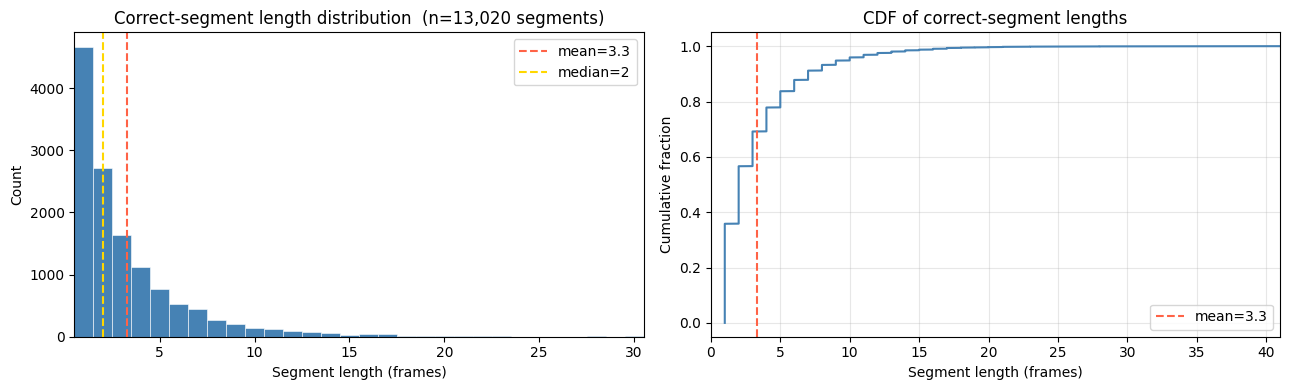

Segments of length 1:    4,664  (36%)
Segments of length <= 3: 9,006  (69%)
Segments of length > 10: 530  (4%)


In [52]:
# Distribution of correct-segment lengths (frames between color switches)
all_runs = [r for pt in results_tracking['per_track'].values() for r in pt['runs']]
all_runs = np.array(all_runs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cap = 30
ax = axes[0]
bins = np.arange(0.5, cap + 1.5)
ax.hist(np.clip(all_runs, 1, cap), bins=bins, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(np.mean(all_runs), color='tomato', lw=1.5, linestyle='--', label=f'mean={np.mean(all_runs):.1f}')
ax.axvline(np.median(all_runs), color='gold', lw=1.5, linestyle='--', label=f'median={int(np.median(all_runs))}')
ax.set_xlabel('Segment length (frames)')
ax.set_ylabel('Count')
ax.set_title(f'Correct-segment length distribution  (n={len(all_runs):,} segments)')
ax.set_xlim(0.5, cap + 0.5)
ax.legend()

ax = axes[1]
sorted_runs = np.sort(all_runs)
cdf = np.arange(1, len(sorted_runs) + 1) / len(sorted_runs)
ax.plot(sorted_runs, cdf, color='steelblue', lw=1.5)
ax.axvline(np.mean(all_runs), color='tomato', lw=1.5, linestyle='--', label=f'mean={np.mean(all_runs):.1f}')
ax.set_xlabel('Segment length (frames)')
ax.set_ylabel('Cumulative fraction')
ax.set_title('CDF of correct-segment lengths')
ax.set_xlim(0, min(sorted_runs.max(), 61))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Segments of length 1:    {(all_runs == 1).sum():,}  ({100*(all_runs==1).mean():.0f}%)")
print(f"Segments of length <= 3: {(all_runs <= 3).sum():,}  ({100*(all_runs<=3).mean():.0f}%)")
print(f"Segments of length > 10: {(all_runs > 10).sum():,}  ({100*(all_runs>10).mean():.0f}%)")

In [49]:
import napari

MIN_TRACK_LEN = 10

scale_arr = np.array([pix_res_vol['z'], pix_res_vol['y'], pix_res_vol['x']], dtype=np.float32)
per_track  = results_tracking['per_track']

rows, rates = [], []
for tid, tpoints in sorted(tracks_pred.items()):
    if len(tpoints) < MIN_TRACK_LEN:
        continue
    rate = float(per_track.get(tid, {}).get('switch_rate', 0.0))
    for t_pt, pos_um in sorted(tpoints.items()):
        pos_px = pos_um / scale_arr
        rows.append([tid, t_pt, pos_px[0], pos_px[1], pos_px[2]])
        rates.append(rate)

track_data  = np.array(rows,  dtype=np.float64)
switch_rate = np.array(rates, dtype=np.float32)

print(f"Tracks shown: {len(set(int(r[0]) for r in rows))} / {len(tracks_pred)} total "
      f"(filtered {sum(1 for t in tracks_pred.values() if len(t) < MIN_TRACK_LEN)} short tracks)")

viewer = napari.Viewer()

vol = np.asarray(vol_track)
for i, ch in enumerate(CH_INDICES):
    viewer.add_image(
        vol[:, ch],
        name=f'Ch{ch}',
        colormap=['red', 'green', 'blue'][i],
        blending='additive',
    )

viewer.add_tracks(
    track_data,
    properties={'switch_rate': switch_rate},
    color_by='switch_rate',
    colormap='turbo',
    name='tracks',
    tail_width=3,
    tail_length=10,
)

Tracks shown: 1615 / 3007 total (filtered 1392 short tracks)


<Tracks layer 'tracks' at 0x782e941b59d0>